In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import date, timedelta
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colors
#warning
import warnings
warnings.filterwarnings('ignore')

In [2]:

dir_topo = 'D:/yuanqi/new urania partition/camels_600.txt'
camels_info = pd.read_csv(dir_topo, delimiter=';')
camels_info = camels_info.sort_values(by='aridity').reset_index(drop=True)
gauge_id = camels_info['gauge_id'].values.astype(np.int64)

In [3]:
sdate = date(1987,1,1)
edate = date(2014,12,31)
ddate = pd.date_range(start=sdate, end=edate, freq='D')

In [4]:
mean_annual_sum_cat = []
for ii in range(0,len(gauge_id)):
    stationid = gauge_id[ii]
    stationid = float(stationid)
    camels_info['gauge_id'] = camels_info['gauge_id'].astype(float)
    aridity = camels_info[camels_info['gauge_id'] == stationid]['aridity'].iloc[0]
    aridity = round(aridity,3)
    stationid = "%08d"%stationid
    # kge
    outd_file = pd.read_csv('D:/yuanqi/1106/sim/'+ str(stationid) + '_AI_' + str(aridity) + '_simulated26.csv',index_col=0)
    outd = outd_file[730:]


    outd.index = ddate


  

    mean_annual_sum = outd.resample('Y').sum().mean().to_frame().T

    mean_annual_sum['AI']=aridity
    mean_annual_sum['catchment id']=stationid



    mean_annual_sum_cat.append(mean_annual_sum)

mean_annual_sum_cat = pd.concat(mean_annual_sum_cat)


In [5]:
datad = pd.read_csv('D:/yuanqi/new urania partition/camels_600.txt',delimiter=';')

In [ ]:
# Select only the two columns you want to keep
mean_annual_sum_cat_rirs = mean_annual_sum_cat[['rs', 'ri', 'qb', 'catchment id' , 'AI']]
# Convert 'catchment id' in mean_annual_sum_cat_rirs to int64
mean_annual_sum_cat_rirs['catchment id'] = mean_annual_sum_cat_rirs['catchment id'].astype(int)

# Merge with datad
datad = datad.merge(mean_annual_sum_cat_rirs, left_on='gauge_id', right_on='catchment id')

In [7]:
datad.to_csv('D:/yuanqi/new urania partition/mean_annual_rirsqb.csv')

##### Land cover info

In [8]:
datad=pd.read_csv('D:/yuanqi/new urania partition/mean_annual_rirsqb.csv')
## Vegetation cover
dir_vegetation = ('D:/yuanqi/new_pdm/camels_attributes_v2.0/camels_attributes_v2.0/')
camels_vege = pd.read_csv(dir_vegetation + "camels_vege.txt",delimiter=';')
camels_climx = pd.read_csv(dir_vegetation + "camels_clim.txt",delimiter=';')              
camels_topo = pd.read_csv(dir_vegetation + "camels_topo.txt",delimiter=';')
camels_topo = camels_topo.merge(camels_climx,left_on='gauge_id',right_on='gauge_id')
camels_vegex = camels_vege.merge(datad, 
                                 on='gauge_id').merge(camels_topo, on='gauge_id')


In [9]:
# xarray
import geopandas as gpd
import xarray 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import proplot as pplt
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
CRS = "EPSG:5070"

In [10]:
### gdf                                                          
camels_vege_finaly_gdf = gpd.GeoDataFrame(camels_vegex, geometry=gpd.points_from_xy(
                             camels_vegex.gauge_lon, camels_vegex.gauge_lat))
camels_vege_finaly_gdf.crs = "EPSG:4326"
camels_vege_finaly_gdf = camels_vege_finaly_gdf.to_crs(CRS)
camels_vege_finaly_gdf['lond'] = np.array(camels_vege_finaly_gdf.geometry.x)
camels_vege_finaly_gdf['latd'] = np.array(camels_vege_finaly_gdf.geometry.y)

#xarray
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdf.to_xarray()
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdfXarray.set_coords(['lond', 'latd'])

In [11]:
conus_states = gpd.read_file('D:/tl_2017_us_state/tl_2017_us_state.shp')

In [16]:
nlevels = [0,50,100,200,500,800,1000,2000,3000]
colors_list = [
    "Red",
    "orange",
    "goldenrod",
    "Yellow",
    "Lime Green",
    "aqua marine",
    "dark sky blue",
    "Blue"
]
# Create discrete colormap
cmap = colors.ListedColormap(colors_list)  
norm = colors.BoundaryNorm(boundaries=nlevels, ncolors=len(nlevels)-1)

ri map

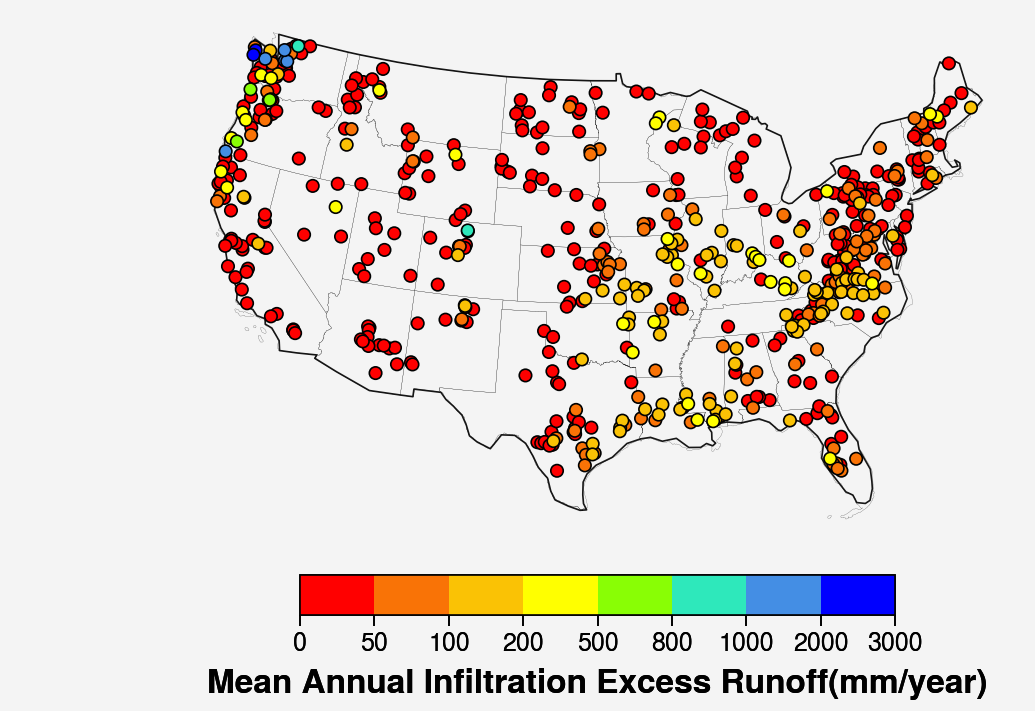

In [17]:
## Ploting
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9,"linewidth":0.07}#  "figsize": (4, 4)}
BASE_PLOT1 = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9}#  "figsize": (4, 4)}



world = gpd.read_file("D:/yuanqi/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


conus = world[world["ADMIN"] == "United States of America"]


#fig, axes = pplt.subplots(nrows=3, ncols=2, share=0,  refheight='2.75')
fig, axes = pplt.subplots(nrows=1, ncols=1, refheight='2.75')
#plt.style.use('science')
#with plt.style.context(['science', 'high-contrast']):
ax = axes

conus_states.to_crs(CRS).plot(ax=ax,**BASE_PLOT)
conus.to_crs(CRS).plot(ax=ax,**BASE_PLOT1)
camels_sorted = camels_vege_finaly_gdfXarray.sortby('ri')

m = xarray.plot.scatter(camels_sorted, x="lond", y="latd", 
                        s=20, hue= 'ri', 
                        edgecolors='k',linewidth=0.075,
                        col_wrap=4, 
                        robust = True, levels = nlevels,
                        cmap=cmap, norm=norm,add_colorbar =False, 
                        ax=ax)        

cm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

ax.colorbar(cm, location="bottom", ticks=nlevels, boundaries = nlevels, length=0.7,

                label= "Mean Annual Infiltration Excess Runoff(mm/year)",

                labelweight='bold', labelsize=12, tickminor=True, shrink = 0.6)                                                                       
ax.format(abc=False, abcloc='ul', titleloc='ul', 
                xlabel='', fontsize= 12)                      
ax.axis(False)    
ax.set_ylim([0,3.3*1e6])
ax.set_xlim([-2.6*1e6,2.5*1e6])
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)

# ##
# axs = plt.axes([0.115, -0.03, 0.8, .32], facecolor='none')
# xarray.plot.hist(camels_vege_finaly_gdfXarray.area_gages2_x)     
# axs.format(xlabel = r'${Catchment Area}$', 
#                 ylabel=r'${Count}$', grid=False)
# axs.text(-0.8, 150, r'$\bf{{{b)}}}$', fontsize= 12)


plt.tight_layout()
plt.savefig('D:/yuanqi/new urania partition/annual_Ri_map.png', **SAVE_KWDS)   

rs map

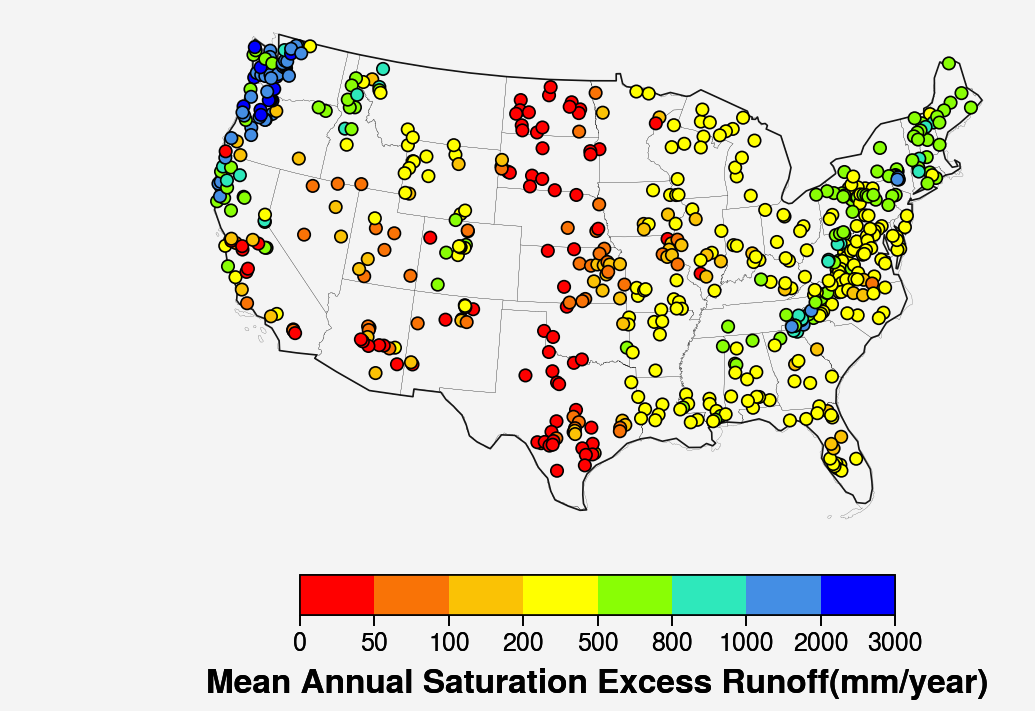

In [18]:
## Ploting
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9,"linewidth":0.07}#  "figsize": (4, 4)}
BASE_PLOT1 = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9}#  "figsize": (4, 4)}


world = gpd.read_file("D:/yuanqi/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


conus = world[world["ADMIN"] == "United States of America"]

#fig, axes = pplt.subplots(nrows=3, ncols=2, share=0,  refheight='2.75')
fig, axes = pplt.subplots(nrows=1, ncols=1, refheight='2.75')
#plt.style.use('science')
#with plt.style.context(['science', 'high-contrast']):
ax = axes

conus_states.to_crs(CRS).plot(ax=ax,**BASE_PLOT)
conus.to_crs(CRS).plot(ax=ax,**BASE_PLOT1)
m = xarray.plot.scatter(camels_vege_finaly_gdfXarray, x="lond", y="latd", 
                        s=20, hue= 'rs', 
                        edgecolors='k',linewidth=0.075,
                        col_wrap=4, 
                        robust = True, levels = nlevels,
                        cmap=cmap, norm=norm,add_colorbar =False, 
                        ax=ax)        

cm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

ax.colorbar(cm, location="bottom", ticks=nlevels, boundaries = nlevels, length=0.7,

                label= "Mean Annual Saturation Excess Runoff(mm/year)",

                labelweight='bold', labelsize=12, tickminor=True, shrink = 0.6)                                                                       
ax.format(abc=False, abcloc='ul', titleloc='ul', 
                xlabel='', fontsize= 12)                      
ax.axis(False)    
ax.set_ylim([0,3.3*1e6])
ax.set_xlim([-2.6*1e6,2.5*1e6])
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)

# ##
# axs = plt.axes([0.115, -0.03, 0.8, .32], facecolor='none')
# xarray.plot.hist(camels_vege_finaly_gdfXarray.area_gages2_x)     
# axs.format(xlabel = r'${Catchment Area}$', 
#                 ylabel=r'${Count}$', grid=False)
# axs.text(-0.8, 150, r'$\bf{{{b)}}}$', fontsize= 12)


plt.tight_layout()
plt.savefig('D:/yuanqi/new urania partition/annual_Rs_map.png', **SAVE_KWDS)   

qb

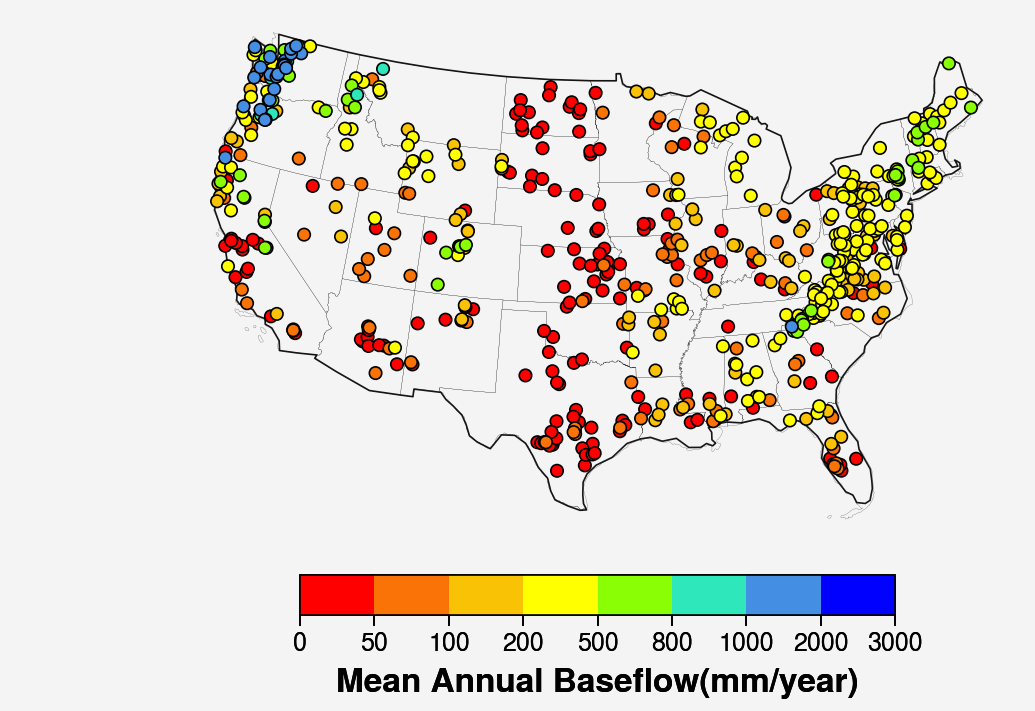

In [19]:
## Ploting
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9,"linewidth":0.07}#  "figsize": (4, 4)}
BASE_PLOT1 = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9}#  "figsize": (4, 4)}



world = gpd.read_file("D:/yuanqi/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


conus = world[world["ADMIN"] == "United States of America"]


#fig, axes = pplt.subplots(nrows=3, ncols=2, share=0,  refheight='2.75')
fig, axes = pplt.subplots(nrows=1, ncols=1, refheight='2.75')
#plt.style.use('science')
#with plt.style.context(['science', 'high-contrast']):
ax = axes

conus_states.to_crs(CRS).plot(ax=ax,**BASE_PLOT)
conus.to_crs(CRS).plot(ax=ax,**BASE_PLOT1)
camels_sorted = camels_vege_finaly_gdfXarray.sortby('qb')
m = xarray.plot.scatter(camels_sorted, x="lond", y="latd", 
                        s=20, hue= 'qb', 
                        edgecolors='k',linewidth=0.075,
                        col_wrap=4, 
                        robust = True, levels = nlevels,
                        cmap=cmap, norm=norm,add_colorbar =False, 
                        ax=ax)        

cm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

ax.colorbar(cm, location="bottom", ticks=nlevels, boundaries = nlevels, length=0.7,

                label= "Mean Annual Baseflow(mm/year)",

                labelweight='bold', labelsize=12, tickminor=True, shrink = 0.6)                                                                       
ax.format(abc=False, abcloc='ul', titleloc='ul', 
                xlabel='', fontsize= 12)                      
ax.axis(False)    
ax.set_ylim([0,3.3*1e6])
ax.set_xlim([-2.6*1e6,2.5*1e6])
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)

# ##
# axs = plt.axes([0.115, -0.03, 0.8, .32], facecolor='none')
# xarray.plot.hist(camels_vege_finaly_gdfXarray.area_gages2_x)     
# axs.format(xlabel = r'${Catchment Area}$', 
#                 ylabel=r'${Count}$', grid=False)
# axs.text(-0.8, 150, r'$\bf{{{b)}}}$', fontsize= 12)


plt.tight_layout()
plt.savefig('D:/yuanqi/new urania partition/annual_Qb_map.png', **SAVE_KWDS)   